# Negociação de Pares — Método Gatev et al. (2006)

Implementa a **fase de negociação** do método de distância, usando os pares já selecionados em `pairs_formation.ipynb`.

Para cada par em cada janela:
1. Normaliza os preços do período de negociação **a partir do início da formação** — mesma base que gerou `spread_media` e `spread_desvio`
2. Calcula o **z-score** do spread usando os parâmetros fixos da formação
3. Abre posição quando `|z| > δ`, fecha quando `z → 0`
4. Retorno diário = `position × (r₁ − r₂)` (portfólio dollar-neutral)

---

## 1. Setup

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === Parâmetros da estratégia ===
DELTA     = 2.0    # gatilho de entrada: abre posição quando |z| > DELTA
STOP      = None   # stop-loss: fecha posição quando |z| > STOP (None = desativado)
SIGMA_MIN = 0.005  # exclui pares com sigma patológico (ghost tickers com sigma ~ 0.00002)

# === Filtro de qualidade de dados ===
# Exclui o par inteiro se qualquer retorno diário no período de NEGOCIAÇÃO
# ultrapassar este limiar em valor absoluto.
# Motivação: retornos >30%/dia indicam OTC penny stocks com dados corrompidos
# (AVATQ: +2450% em 05/dez/2007; PNAA: +5686% em 26/dez/2007).
# None = sem filtro.
MAX_RETORNO_DIA = 0.90

# === Convenção do portfólio ===
# True  — "committed capital" (Gatev et al., 2006):
#         denominador = N pares fixo; pares inativos contribuem 0.
# False — "fully invested":
#         denominador = pares com posição ativa no dia.
COMMITTED_CAPITAL = True

# === Filtro de período (mês no formato 'YYYY-MM') ===
PERIODO_INICIO = None  # ex: '1992-01'
PERIODO_FIM    = None  # ex: '2015-12'

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 2. Carregando os dados

In [62]:
pares_raw = pd.read_csv('output/pares_formados.csv')
# df        = pd.read_csv('../../data_bases/base_completa.csv', parse_dates=['date'])
df        = pd.read_csv('../../data_bases/base_unificada.csv', parse_dates=['date'])
df        = df.set_index('date')

colunas_preco   = [c for c in df.columns if c not in META_COLS]
meses_por_linha = pd.PeriodIndex(df.index, freq='M')

# Aplica filtro de período sobre os meses de negociação
pares = pares_raw.copy()
if PERIODO_INICIO is not None:
    pares = pares[pares['negociacao_inicio'] >= PERIODO_INICIO]
if PERIODO_FIM is not None:
    pares = pares[pares['negociacao_fim'] <= PERIODO_FIM]

print(f"Pares disponíveis : {len(pares_raw):,} ({pares_raw['janela'].nunique()} janelas)")
if PERIODO_INICIO or PERIODO_FIM:
    ini = PERIODO_INICIO or pares_raw['negociacao_inicio'].min()
    fim = PERIODO_FIM    or pares_raw['negociacao_fim'].max()
    print(f"Período filtrado  : {ini} → {fim}  ({len(pares):,} pares, {pares['janela'].nunique()} janelas)")
else:
    print("Período filtrado  : todo o histórico")
print(f"Base de preços    : {df.shape[0]:,} dias × {len(colunas_preco):,} tickers")

Pares disponíveis : 8,180 (409 janelas)
Período filtrado  : todo o histórico
Base de preços    : 8,939 dias × 1,343 tickers


## 3. Lógica de negociação

### Z-score
No período de negociação, os preços são normalizados usando **o mesmo ponto zero da formação**: $Q_i(t) = P_i(t) / P_i(t_{\text{formação início}})$.

O z-score usa os parâmetros fixos da formação:
$$z(t) = \frac{Q_1(t) - Q_2(t) - \bar{s}}{\sigma}$$

### Regras de entrada e saída

| Condição | Posição | Lógica |
|---|---|---|
| $z > +\delta$ | `-1` (vende ativo1, compra ativo2) | spread acima da média → espera reversão |
| $z < -\delta$ | `+1` (compra ativo1, vende ativo2) | spread abaixo da média → espera reversão |
| $z \to 0$ | `0` (fecha) | reversão concluída |
| `\|z\| > stop` | `0` (fecha) | stop-loss |
| fim do período de negociação | `0` (fecha forçado) | encerra todas as posições abertas |

### Lag de posição (convenção de execução)

A decisão de abrir/fechar é tomada ao **fechamento do dia $t$**, depois de observar $z(t)$. A execução (e portanto o retorno) começa apenas no **dia $t+1$**. Isso implica:

$$r_{\text{par}}(t) = \text{position}(t-1) \times [r_1(t) - r_2(t)]$$

Consequências práticas:
- **Dia de abertura $t$**: `position(t-1) = 0` → retorno zero (correto: ainda não estávamos no par)
- **Dia de fechamento $t$**: `position(t-1) ≠ 0` → retorno capturado (correto: seguramos o par durante o dia)

Implementado via `np.roll(positions, 1)` — cada dia usa a posição registrada no dia anterior.

> **Janelas sobrepostas.** Com `PASSO_MESES = 1` na formação, até `MESES_NEGOCIACAO` carteiras (cohorts) ficam ativas em paralelo. O portfólio diário é a média de **todos** os pares ativos no dia, somando as carteiras sobrepostas — mesma convenção do notebook de cointegração.

In [63]:
def simular_par(precos_form, precos_neg, mu, sigma, delta=DELTA, stop=STOP):
    """
    Simula a negociação de um par durante o período de negociação.

    precos_form : DataFrame (T × 2) com preços no período de formação
    precos_neg  : DataFrame (τ × 2) com preços no período de negociação
    mu, sigma   : média e desvio do spread calculados na formação

    Retorna DataFrame com colunas [z, position, position_lag, retorno_diario]
    ou None se a simulação não for possível.
    """
    if sigma == 0:
        return None

    a1, a2 = precos_form.columns[0], precos_form.columns[1]

    # Ponto 1: garante ordenação cronológica antes de usar iloc[0]
    precos_form = precos_form.sort_index()
    precos_neg  = precos_neg.sort_index()

    # Normaliza o período de negociação a partir do início da formação
    P0    = precos_form.iloc[0]
    Q_neg = precos_neg / P0

    # Z-score com parâmetros fixos da formação
    spread = Q_neg[a1] - Q_neg[a2]
    z      = (spread - mu) / sigma
    z_arr  = z.values

    # Simula posições dia a dia (signal — sem lag)
    positions = np.zeros(len(z_arr))
    pos = 0
    for t, zt in enumerate(z_arr):
        if pos == 0:
            if zt > delta:
                pos = -1   # vende a1, compra a2
            elif zt < -delta:
                pos = +1   # compra a1, vende a2
        else:
            if stop is not None and abs(zt) > stop:
                pos = 0    # stop-loss
            elif pos == +1 and zt >= 0:
                pos = 0    # fecha posição longa (spread reverteu)
            elif pos == -1 and zt <= 0:
                pos = 0    # fecha posição curta (spread reverteu)
        positions[t] = pos

    # Ponto 4: pct_change com fillna(0) — primeiro retorno do semestre é 0 por definição
    r1 = precos_neg[a1].pct_change().fillna(0).values
    r2 = precos_neg[a2].pct_change().fillna(0).values

    # Ponto 2: lag de posição
    # A decisão ao fechamento de t é executada a partir de t+1.
    # position_lag[t] = positions[t-1]:
    #   - dia de abertura: position_lag = 0  → retorno = 0 (ainda não estávamos no par)
    #   - dia de fechamento: position_lag = pos anterior → retorno capturado corretamente
    positions_lag    = np.roll(positions, 1)
    positions_lag[0] = 0  # antes do primeiro dia não havia posição

    return pd.DataFrame({
        'z':             z_arr,
        'position':      positions,      # sinal sem lag (usar em contar_trades e nos plots)
        'position_lag':  positions_lag,  # posição efetiva que gerou o retorno do dia
        'retorno_diario': positions_lag * (r1 - r2),
    }, index=z.index)


def contar_trades(positions):
    """Retorna (n_abertos, n_fechados_normal, n_forcados).
    Usa o sinal sem lag — conta as transições de posição."""
    pos = np.asarray(positions)
    entradas = np.sum((pos[1:] != 0) & (pos[:-1] == 0))
    if pos[0] != 0:
        entradas += 1
    saidas_normais = np.sum((pos[:-1] != 0) & (pos[1:] == 0))
    forcado = 1 if pos[-1] != 0 else 0
    return int(entradas), int(saidas_normais), int(forcado)

## 4. Simulação completa

> **Pré-requisito:** `pares_formados.csv` deve ter sido gerado com `TOP_K = 20` em `pairs_formation.ipynb`.

Para cada par, **quatro filtros de exclusão** são aplicados antes de acumular o resultado:
1. `sigma < SIGMA_MIN` — ghost tickers têm sigma ~ 0.00002; pares reais ~ 0.015+
2. Ticker não encontrado na base de preços
3. Dados ausentes no período de formação ou negociação
4. `MAX_RETORNO_DIA` — exclui pares cujos ativos tenham qualquer retorno diário acima do limiar. Isso elimina OTC penny stocks com dados corrompidos que apareceriam como pares legítimos (AVATQ, PNAA com preços de `$0.0001` e retornos de +2450% / +5686% num único dia)

In [64]:
resultados_pares  = []
retornos_por_data = {}

n_skip_sigma    = 0
n_skip_ticker   = 0
n_skip_dados    = 0
n_skip_outlier  = 0

for _, par in pares.iterrows():
    a1    = par['ativo1']
    a2    = par['ativo2']
    mu    = par['spread_media']
    sigma = par['spread_desvio']

    # Filtro 1: sigma patologicamente pequeno (ghost tickers)
    if sigma < SIGMA_MIN:
        n_skip_sigma += 1
        continue

    # Filtro 2: ticker ausente na base de preços
    if a1 not in df.columns or a2 not in df.columns:
        n_skip_ticker += 1
        continue

    # Recortes por mês calendário (mesma convenção da formação)
    form_inicio = pd.Period(par['formacao_inicio'],   freq='M')
    form_fim    = pd.Period(par['formacao_fim'],      freq='M')
    neg_inicio  = pd.Period(par['negociacao_inicio'], freq='M')
    neg_fim     = pd.Period(par['negociacao_fim'],    freq='M')

    mask_form = (meses_por_linha >= form_inicio) & (meses_por_linha <= form_fim)
    mask_neg  = (meses_por_linha >= neg_inicio)  & (meses_por_linha <= neg_fim)

    precos_form = df.loc[mask_form, [a1, a2]].dropna()
    precos_neg  = df.loc[mask_neg,  [a1, a2]].dropna()

    # Filtro 3: dados ausentes
    if len(precos_form) == 0 or len(precos_neg) == 0:
        n_skip_dados += 1
        continue

    # Filtro 4: spike positivo extremo = corrupção de dados (AVATQ +2450%, PNAA +5686%)
    # Usamos .max() em vez de .abs().max(): quedas reais (falências) são preservadas e
    # a perda é contabilizada. Apenas spikes positivos absurdos, que indicam dado corrompido,
    # excluem o par.
    if MAX_RETORNO_DIA is not None:
        r_max_pos = precos_neg.pct_change().max().max()
        if r_max_pos > MAX_RETORNO_DIA:
            n_skip_outlier += 1
            continue

    resultado = simular_par(precos_form, precos_neg, mu, sigma)
    if resultado is None:
        continue

    n_abertos, n_fechados, n_forcados = contar_trades(resultado['position'].values)

    resultados_pares.append({
        'janela'        : par['janela'],
        'neg_inicio'    : par['negociacao_inicio'],
        'neg_fim'       : par['negociacao_fim'],
        'ativo1'        : a1,
        'ativo2'        : a2,
        'rank'          : par['rank'],
        'ssd'           : par['ssd'],
        'sigma'         : sigma,
        'n_trades'      : n_abertos,
        'n_fechados'    : n_fechados,
        'n_forcados'    : n_forcados,
        'retorno_total' : resultado['retorno_diario'].sum(),
    })

    # Acumula retornos diários para o portfólio.
    #
    # COMMITTED_CAPITAL=True (Gatev): o par entra no denominador em TODOS os dias
    # do período de negociação — inclusive após um eventual delisting (dias sem preço).
    # Nesses dias ausentes, o par contribui 0 (capital fica em caixa).
    # Isso evita que o denominador encolha quando um papel desaparece, o que inflaria
    # artificialmente o retorno dos pares sobreviventes.
    #
    # COMMITTED_CAPITAL=False: só dias com posição ativa entram na média.
    #
    # Com janelas sobrepostas (PASSO_MESES < MESES_NEGOCIACAO) as carteiras coexistem:
    # a média diária é tirada sobre todos os pares ativos, de todas as janelas.
    if COMMITTED_CAPITAL:
        ret_dict  = resultado['retorno_diario'].to_dict()
        all_dates = df.index[mask_neg]          # todos os dias de pregão do período
        for date in all_dates:
            retornos_por_data.setdefault(date, []).append(ret_dict.get(date, 0.0))
    else:
        for date, row in resultado.iterrows():
            if row['position_lag'] != 0:
                retornos_por_data.setdefault(date, []).append(row['retorno_diario'])

resultados_df = pd.DataFrame(resultados_pares)

print(f"Total de pares no arquivo  : {len(pares):,}")
print(f"  Pulados (sigma < {SIGMA_MIN}) : {n_skip_sigma:,}")
print(f"  Pulados (ticker ausente)  : {n_skip_ticker:,}")
print(f"  Pulados (sem dados)       : {n_skip_dados:,}")
print(f"  Pulados (spike positivo)  : {n_skip_outlier:,}  ← corrupção de dados filtrada")
print(f"  Simulados com sucesso     : {len(resultados_df):,}")

Total de pares no arquivo  : 8,180
  Pulados (sigma < 0.005) : 22
  Pulados (ticker ausente)  : 0
  Pulados (sem dados)       : 18
  Pulados (spike positivo)  : 16  ← corrupção de dados filtrada
  Simulados com sucesso     : 8,124


## 5. Resultado por par

## 4.1 Diagnóstico — pares simulados por janela

Mostra quantos pares foram efetivamente simulados em cada janela de negociação (identificada pelo mês inicial).
Com `TOP_K = 20`, espera-se **10–18 pares válidos** por janela na era do professor e **15–20** na extensão.

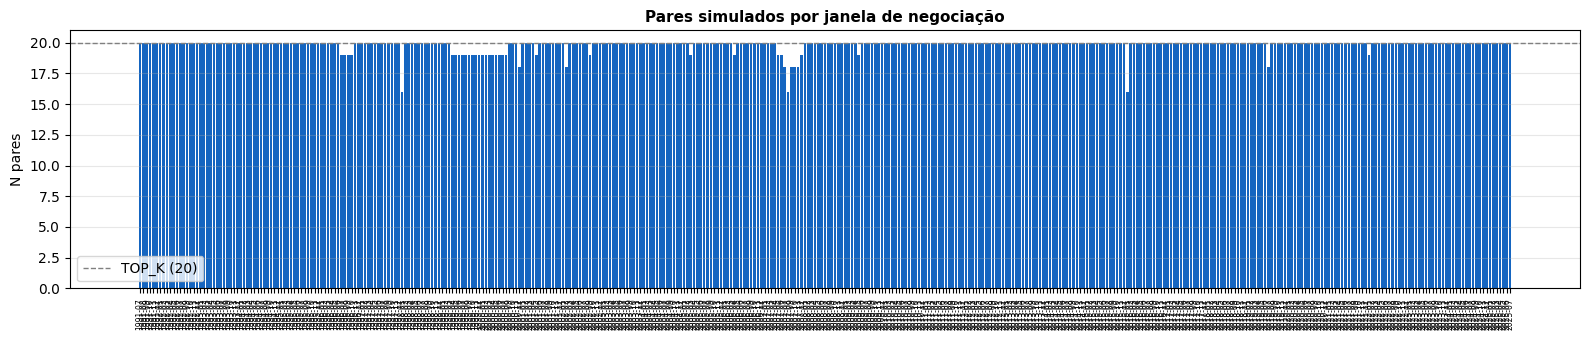

Janelas com 0 pares simulados : 0
Média de pares por janela     : 19.9
Mínimo / Máximo               : 16 / 20


In [65]:
# Pares simulados por janela de negociação
pares_por_janela = (
    resultados_df
    .groupby('neg_inicio')['ativo1']
    .count()
    .reset_index()
    .rename(columns={'ativo1': 'n_simulados'})
    .sort_values('neg_inicio')
)

fig, ax = plt.subplots(figsize=(16, 3.5))
cores = ['#1565C0' if n >= 10 else '#ef5350' for n in pares_por_janela['n_simulados']]
ax.bar(pares_por_janela['neg_inicio'], pares_por_janela['n_simulados'], color=cores)
ax.axhline(pares['rank'].max(), color='gray', lw=1.0, ls='--', label=f'TOP_K ({pares["rank"].max()})')
ax.set_title('Pares simulados por janela de negociação', fontsize=11, fontweight='bold')
ax.set_ylabel('N pares')
ax.tick_params(axis='x', rotation=90, labelsize=5.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Janelas com 0 pares simulados : {(pares_por_janela['n_simulados'] == 0).sum()}")
print(f"Média de pares por janela     : {pares_por_janela['n_simulados'].mean():.1f}")
print(f"Mínimo / Máximo               : {pares_por_janela['n_simulados'].min()} / {pares_por_janela['n_simulados'].max()}")

In [66]:
pares_com_trade = resultados_df[resultados_df['n_trades'] > 0]

print("=== Estatísticas de trades ===")
print(f"Pares que abriram ≥ 1 trade    : {len(pares_com_trade):,} de {len(resultados_df):,}")
print(f"Total de trades abertos        : {resultados_df['n_trades'].sum():,}")
print(f"Trades fechados normalmente    : {resultados_df['n_fechados'].sum():,}")
print(f"Trades forçados (fim período)  : {resultados_df['n_forcados'].sum():,}")

taxa_convergencia = resultados_df['n_fechados'].sum() / resultados_df['n_trades'].sum()
print(f"\nTaxa de convergência           : {taxa_convergencia:.1%}")

print("\n=== Retorno por par (todos os pares) ===")
print(resultados_df['retorno_total'].describe().to_string())

=== Estatísticas de trades ===
Pares que abriram ≥ 1 trade    : 7,929 de 8,124
Total de trades abertos        : 15,779
Trades fechados normalmente    : 9,387
Trades forçados (fim período)  : 6,392

Taxa de convergência           : 59.5%

=== Retorno por par (todos os pares) ===
count    8124.000000
mean        0.029819
std         0.152701
min        -1.142724
25%        -0.032907
50%         0.013227
75%         0.071965
max         2.371110


In [67]:
# Top e bottom pares por retorno total
print("Top 10 pares por retorno total:")
display(
    resultados_df
    .nlargest(10, 'retorno_total')
    [['neg_inicio', 'ativo1', 'ativo2', 'rank', 'n_trades', 'n_fechados', 'retorno_total']]
    .reset_index(drop=True)
)

print("\nBottom 10 pares por retorno total:")
display(
    resultados_df
    .nsmallest(10, 'retorno_total')
    [['neg_inicio', 'ativo1', 'ativo2', 'rank', 'n_trades', 'n_fechados', 'retorno_total']]
    .reset_index(drop=True)
)

Top 10 pares por retorno total:


,neg_inicio,ativo1,ativo2,rank,n_trades,n_fechados,retorno_total
0,2008-09,MHFI,SPGI,2,15,15,2.371110
1,2008-08,MHFI,SPGI,1,14,14,2.143101
2,2008-07,MHFI,SPGI,1,13,13,2.042853
3,2008-06,MHFI,SPGI,1,13,13,1.969680
4,2008-10,MHFI,SPGI,9,10,10,1.823595
5,2008-05,MHFI,SPGI,2,13,12,1.577780
6,2011-08,BF_B,1958Q,1,28,28,1.324640
7,2000-03,571300Q,VZ,8,3,2,1.306047
8,2011-07,BF_B,1958Q,6,27,27,1.287158
9,2011-07,MHFI,SPGI,7,24,24,1.286970



Bottom 10 pares por retorno total:


,neg_inicio,ativo1,ativo2,rank,n_trades,n_fechados,retorno_total
0,2008-06,8394653Q,PLD,11,2,1,-1.142724
1,2007-06,TMK,ABKFQ,10,1,0,-0.900480
2,2007-05,TMK,ABKFQ,16,1,0,-0.774742
3,2007-05,SCHW,ABKFQ,13,2,1,-0.761595
4,2002-07,TXU,SCG,20,1,0,-0.760775
5,2008-10,DOW,ITW,19,2,1,-0.627731
6,2008-08,BVSN,NI,9,1,0,-0.617488
7,2024-09,EIX,NI,4,1,0,-0.588758
8,2004-06,KO,STR,20,1,0,-0.547256
9,2008-09,9876566D,TMK,13,2,1,-0.504388


## 6. Portfólio e curva de equity

O retorno diário do portfólio é a **média dos retornos de todos os pares** na convenção escolhida:

- **`COMMITTED_CAPITAL = True`** (Gatev et al., 2006): todos os N pares entram no denominador todos os dias. Pares sem posição contribuem 0. É a convenção do paper original.
- **`COMMITTED_CAPITAL = False`** ("fully invested"): apenas pares com posição ativa entram na média. Retorno mais alto, mas mais concentrado quando poucas posições abertas.

Com o **lag de posição**, o retorno de cada dia usa `position(t-1)`, garantindo que o par apenas começa a contribuir no dia seguinte à abertura.

In [68]:
# Retorno diário do portfólio = média dos retornos de todos os pares naquele dia
portfolio = pd.Series(
    {date: np.mean(rets) for date, rets in retornos_por_data.items()}
).sort_index()

# Equity acumulada
equity = (1 + portfolio).cumprod()

print(f"Período do portfólio: {portfolio.index[0].date()} → {portfolio.index[-1].date()}")
print(f"Dias de negociação  : {len(portfolio):,}")
print(f"Retorno diário médio: {portfolio.mean():.4%}")
print(f"Retorno acumulado   : {equity.iloc[-1] - 1:.2%}")

Período do portfólio: 1991-07-01 → 2025-12-31
Dias de negociação  : 8,688
Retorno diário médio: 0.0238%
Retorno acumulado   : 672.19%


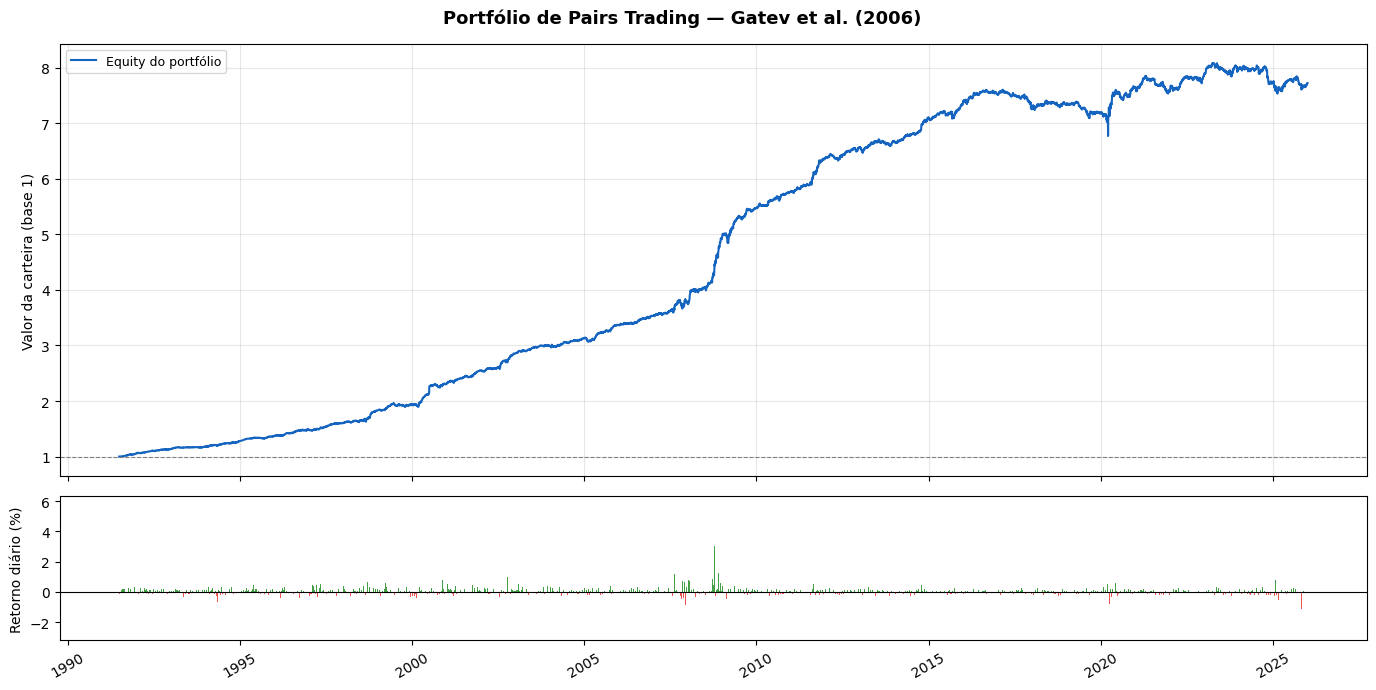

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle("Portfólio de Pairs Trading — Gatev et al. (2006)", fontsize=13, fontweight='bold')

# Curva de equity
ax_eq = axes[0]
ax_eq.plot(equity.index, equity.values, color='#1565C0', lw=1.5, label='Equity do portfólio')
ax_eq.axhline(1, color='gray', lw=0.8, ls='--')
ax_eq.set_ylabel('Valor da carteira (base 1)', fontsize=10)
ax_eq.legend(fontsize=9)
ax_eq.grid(alpha=0.3)

# Retornos diários
ax_ret = axes[1]
colors = ['#ef5350' if r < 0 else '#43A047' for r in portfolio.values]
ax_ret.bar(portfolio.index, portfolio.values * 100, color=colors, width=1)
ax_ret.axhline(0, color='black', lw=0.8)
ax_ret.set_ylabel('Retorno diário (%)', fontsize=10)
ax_ret.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_ret.xaxis.set_major_locator(mdates.YearLocator(5))
ax_ret.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Métricas de performance

In [70]:
# Sharpe ratio anualizado (assumindo 252 dias de pregão)
sharpe = portfolio.mean() / portfolio.std() * np.sqrt(252)

# Drawdown máximo
rolling_max = equity.cummax()
drawdown    = (equity - rolling_max) / rolling_max
max_dd      = drawdown.min()

# Retorno anualizado
n_anos = len(portfolio) / 252
retorno_anualizado = equity.iloc[-1] ** (1 / n_anos) - 1

# Percentual de dias com retorno positivo
dias_positivos = (portfolio > 0).mean()

print("=" * 40)
print("     MÉTRICAS DE PERFORMANCE")
print("=" * 40)
print(f"Retorno acumulado      : {equity.iloc[-1] - 1:>+.2%}")
print(f"Retorno anualizado     : {retorno_anualizado:>+.2%}")
print(f"Volatilidade anual     : {portfolio.std() * np.sqrt(252):>.2%}")
print(f"Sharpe ratio           : {sharpe:>+.2f}")
print(f"Drawdown máximo        : {max_dd:>+.2%}")
print(f"Dias com retorno > 0   : {dias_positivos:.1%}")
print("=" * 40)

     MÉTRICAS DE PERFORMANCE
Retorno acumulado      : +672.19%
Retorno anualizado     : +6.11%
Volatilidade anual     : 3.43%
Sharpe ratio           : +1.75
Drawdown máximo        : -10.95%
Dias com retorno > 0   : 54.4%


### 7.1 Retorno bruto × retorno líquido de renda fixa

As mesmas métricas acima, calculadas sobre **duas séries**:

- **bruto** — $r_p(t)$, o retorno do portfólio exatamente como calculado na célula anterior
- **líquido** — $r_p(t) - r_f(t)$, subtraindo a taxa livre de risco diária

A taxa vem de `rf_diario.csv` (Rf do professor até 2015-12-30 + T-bill de 3 meses do FRED de 2016 em diante), gerado por [`serie_rf.ipynb`](../database_formation/serie_rf.ipynb).

> **Convenção dos artigos.** Gatev et al. (2006, nota 5) e Sabino da Silva, Ziegelmann & Caldeira (2023, nota 10) calculam o retorno de capital comprometido assumindo **juro zero sobre o caixa ocioso**, e já chamam esse número de *excess return* — sem subtrair $r_f$. Gatev descreve a escolha como conservadora, que *"understates the computed excess returns"*. A coluna **líquido** aplica a subtração explícita, para comparação direta.
>
> Note que subtrair $r_f$ reduz a média mas **não** altera a volatilidade, então o efeito recai quase todo sobre o Sharpe.

In [71]:
# ── Retorno bruto × retorno líquido de renda fixa ─────────────────────────────
PATH_RF = '../../data_bases/rf_diario.csv'

rf = pd.read_csv(PATH_RF, parse_dates=['date']).set_index('date')['rf']
rf = rf.reindex(portfolio.index)

if rf.isna().any():
    print(f"⚠ {rf.isna().sum()} dia(s) do portfólio sem taxa — preenchidos com o último valor disponível.\n")
    rf = rf.ffill().bfill()

portfolio_liquido = portfolio - rf


def metricas_performance(serie):
    """Métricas anualizadas de uma série de retornos diários."""
    equity  = (1 + serie).cumprod()
    maxacum = equity.cummax()
    n_anos  = len(serie) / 252
    return {
        'Retorno acumulado'    : equity.iloc[-1] - 1,
        'Retorno anualizado'   : equity.iloc[-1] ** (1 / n_anos) - 1,
        'Média diária × 252'   : serie.mean() * 252,
        'Volatilidade anual'   : serie.std() * np.sqrt(252),
        'Sharpe ratio'         : serie.mean() / serie.std() * np.sqrt(252),
        'Drawdown máximo'      : ((equity - maxacum) / maxacum).min(),
        'Dias com retorno > 0' : (serie > 0).mean(),
    }


bruto   = metricas_performance(portfolio)
liquido = metricas_performance(portfolio_liquido)

rf_aa = (1 + rf.mean()) ** 252 - 1
print(f"Renda fixa no período : {rf_aa:.2%} a.a. (média diária de {rf.mean():.6f})")
print(f"Período               : {portfolio.index[0].date()} → {portfolio.index[-1].date()}  "
      f"({len(portfolio):,} dias)")
print()

print("=" * 66)
print("   MÉTRICAS DE PERFORMANCE — bruto × líquido de renda fixa")
print("=" * 66)
print(f"{'':<24}{'bruto':>13}{'líquido':>13}{'diferença':>14}")
print("-" * 66)
SEM_SINAL = {'Volatilidade anual', 'Dias com retorno > 0'}
for nome in bruto:
    b, l, d = bruto[nome], liquido[nome], liquido[nome] - bruto[nome]
    if nome == 'Sharpe ratio':
        print(f"{nome:<24}{b:>13.2f}{l:>13.2f}{d:>+14.2f}")
    elif nome in SEM_SINAL:
        print(f"{nome:<24}{b:>13.2%}{l:>13.2%}{d:>+14.2%}")
    else:
        print(f"{nome:<24}{b:>+13.2%}{l:>+13.2%}{d:>+14.2%}")
print("=" * 66)

Renda fixa no período : 2.51% a.a. (média diária de 0.000098)
Período               : 1991-07-01 → 2025-12-31  (8,688 dias)

   MÉTRICAS DE PERFORMANCE — bruto × líquido de renda fixa
                                bruto      líquido     diferença
------------------------------------------------------------------
Retorno acumulado            +672.19%     +228.45%      -443.74%
Retorno anualizado             +6.11%       +3.51%        -2.60%
Média diária × 252             +5.99%       +3.51%        -2.48%
Volatilidade anual              3.43%        3.43%        +0.00%
Sharpe ratio                     1.75         1.02         -0.72
Drawdown máximo               -10.95%      -18.48%        -7.53%
Dias com retorno > 0           54.44%       51.82%        -2.62%


Meses positivos: 293 de 414  (71%)


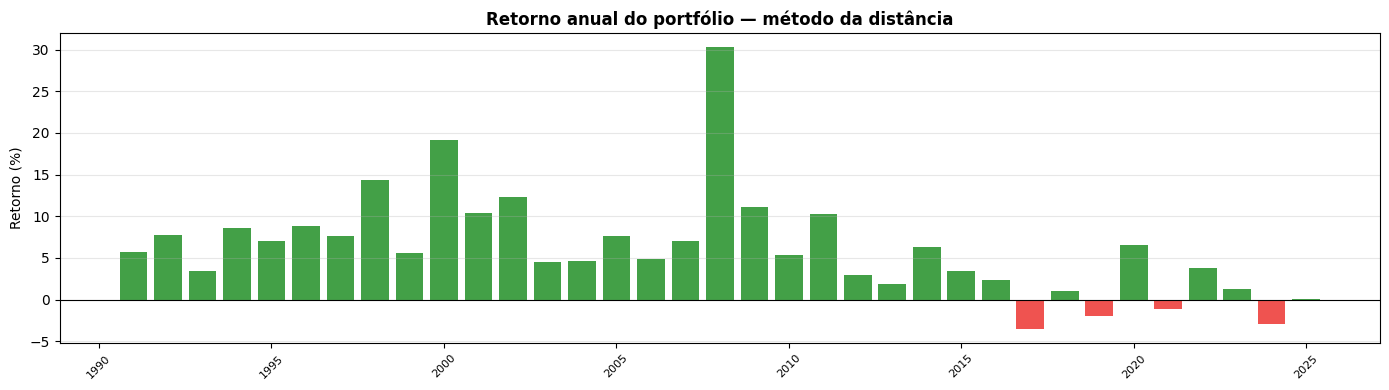

In [72]:
# Retorno por mês de negociação
port_df = portfolio.to_frame('retorno')
port_df['ano'] = port_df.index.year
port_df['mes'] = port_df.index.month
port_df['ano_mes'] = port_df.index.to_period('M').astype(str)

retorno_mensal = (
    port_df.groupby('ano_mes')['retorno']
    .apply(lambda r: (1 + r).prod() - 1)
    .reset_index()
    .rename(columns={'retorno': 'retorno_mensal'})
)

print(f"Meses positivos: {(retorno_mensal['retorno_mensal'] > 0).sum()} "
      f"de {len(retorno_mensal)}  ({(retorno_mensal['retorno_mensal'] > 0).mean():.0%})")

# Agrega por ano para o gráfico (menos poluído)
retorno_anual = (
    port_df.groupby('ano')['retorno']
    .apply(lambda r: (1 + r).prod() - 1)
    .reset_index()
    .rename(columns={'retorno': 'retorno_anual'})
)

fig, ax = plt.subplots(figsize=(14, 4))
cores = ['#43A047' if r > 0 else '#ef5350' for r in retorno_anual['retorno_anual']]
ax.bar(retorno_anual['ano'], retorno_anual['retorno_anual'] * 100, color=cores)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Retorno anual do portfólio — método da distância', fontsize=12, fontweight='bold')
ax.set_ylabel('Retorno (%)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Explorando um par específico

Altere as variáveis abaixo para visualizar qualquer par em qualquer janela.

In [73]:
# === Configuração: escolha o par a explorar ===
NEG_INICIO_ALVO = '2020-07'   # mês inicial do período de negociação ('YYYY-MM')
RANK_ALVO       = 1           # rank do par (1–TOP_K)

sel = pares[
    (pares['negociacao_inicio'] == NEG_INICIO_ALVO) &
    (pares['rank'] == RANK_ALVO)
]
if sel.empty:   # a janela pedida não existe na grade atual — usa a primeira disponível
    NEG_INICIO_ALVO = pares['negociacao_inicio'].iloc[0]
    sel = pares[
        (pares['negociacao_inicio'] == NEG_INICIO_ALVO) &
        (pares['rank'] == RANK_ALVO)
    ]

par_info = sel.iloc[0]

print(f"Par selecionado : {par_info['ativo1']} / {par_info['ativo2']}")
print(f"Janela          : {par_info['janela']}")
print(f"Negociação      : {par_info['negociacao_inicio']} → {par_info['negociacao_fim']}")
print(f"SSD             : {par_info['ssd']:.6f}")
print(f"Spread μ        : {par_info['spread_media']:.6f}")
print(f"Spread σ        : {par_info['spread_desvio']:.6f}")

Par selecionado : CMS / LNT
Janela          : 2019-07_a_2020-06
Negociação      : 2020-07 → 2020-12
SSD             : 0.116350
Spread μ        : -0.000776
Spread σ        : 0.021473


In [74]:
a1 = par_info['ativo1']
a2 = par_info['ativo2']

# Carrega preços (recorte por mês calendário)
form_inicio = pd.Period(par_info['formacao_inicio'],   freq='M')
form_fim    = pd.Period(par_info['formacao_fim'],      freq='M')
neg_inicio  = pd.Period(par_info['negociacao_inicio'], freq='M')
neg_fim     = pd.Period(par_info['negociacao_fim'],    freq='M')

mask_form = (meses_por_linha >= form_inicio) & (meses_por_linha <= form_fim)
mask_neg  = (meses_por_linha >= neg_inicio)  & (meses_por_linha <= neg_fim)

precos_form = df.loc[mask_form, [a1, a2]].dropna()
precos_neg  = df.loc[mask_neg,  [a1, a2]].dropna()

# Simula
resultado = simular_par(precos_form, precos_neg, par_info['spread_media'], par_info['spread_desvio'])

if resultado is None:
    print("Par não pode ser simulado (sigma = 0 ou dados ausentes).")
else:
    n_ab, n_fec, n_for = contar_trades(resultado['position'].values)
    retorno = resultado['retorno_diario'].sum()
    print(f"Trades abertos  : {n_ab}")
    print(f"Fechados (z→0)  : {n_fec}")
    print(f"Forçados        : {n_for}")
    print(f"Retorno total   : {retorno:+.4%}")

Trades abertos  : 3
Fechados (z→0)  : 3
Forçados        : 0
Retorno total   : +14.9052%


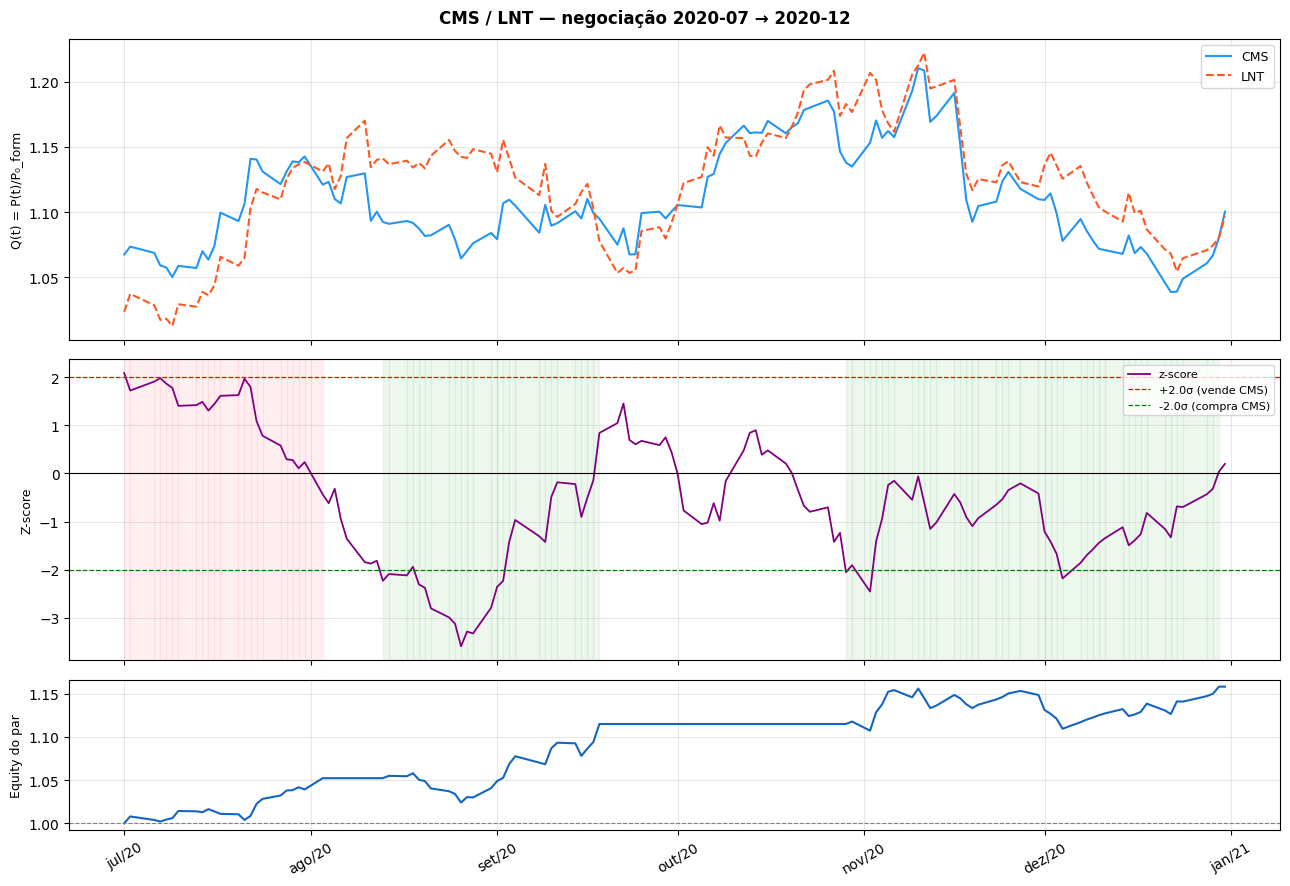

In [75]:
if resultado is not None:
    # Preços normalizados (Q) no período de negociação
    P0    = precos_form.sort_index().iloc[0]
    Q_neg = precos_neg / P0
    equity_par = (1 + resultado['retorno_diario']).cumprod()

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                              gridspec_kw={'height_ratios': [2, 2, 1]})
    fig.suptitle(
        f"{a1} / {a2} — negociação {par_info['negociacao_inicio']} → {par_info['negociacao_fim']}",
        fontsize=12, fontweight='bold')

    # Painel 1: preços normalizados Q(t)
    ax1 = axes[0]
    ax1.plot(Q_neg.index, Q_neg[a1], color='#2196F3', lw=1.5, label=a1)
    ax1.plot(Q_neg.index, Q_neg[a2], color='#FF5722', lw=1.5, ls='--', label=a2)
    ax1.set_ylabel('Q(t) = P(t)/P₀_form', fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # Painel 2: z-score com sinais de entrada/saída
    ax2 = axes[1]
    ax2.plot(resultado.index, resultado['z'], color='purple', lw=1.3, label='z-score')
    ax2.axhline(0,      color='black', lw=0.8)
    ax2.axhline(+DELTA, color='red',   lw=0.9, ls='--', label=f'+{DELTA}σ (vende {a1})')
    ax2.axhline(-DELTA, color='green', lw=0.9, ls='--', label=f'-{DELTA}σ (compra {a1})')
    if STOP is not None:
        ax2.axhline(+STOP, color='red',   lw=0.7, ls=':', alpha=0.5)
        ax2.axhline(-STOP, color='green', lw=0.7, ls=':', alpha=0.5)

    # Sombreia períodos com posição aberta
    pos = resultado['position'].values
    datas = resultado.index
    for t in range(len(pos)):
        if pos[t] != 0:
            cor = '#FFCDD2' if pos[t] == -1 else '#C8E6C9'
            ax2.axvspan(datas[t], datas[min(t+1, len(datas)-1)], alpha=0.3, color=cor)

    ax2.set_ylabel('Z-score', fontsize=9)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(alpha=0.3)

    # Painel 3: equity acumulada do par
    ax3 = axes[2]
    ax3.plot(equity_par.index, equity_par.values, color='#1565C0', lw=1.5)
    ax3.axhline(1, color='gray', lw=0.8, ls='--')
    ax3.set_ylabel('Equity do par', fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax3.tick_params(axis='x', rotation=30)
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Salvando resultados

In [76]:
# Resultado por par
resultados_df.to_csv('output/negociacao_pares.csv', index=False)

# Retornos diários do portfólio
portfolio.to_frame('retorno_diario').to_csv('output/negociacao_portfolio.csv')

print("Salvo:")
print("  output/negociacao_pares.csv     — resultado por par (trades, retorno)")
print("  output/negociacao_portfolio.csv — retorno diário do portfólio")

Salvo:
  output/negociacao_pares.csv     — resultado por par (trades, retorno)
  output/negociacao_portfolio.csv — retorno diário do portfólio
